# Imports

In [1]:
import sys
sys.path.insert(1, '../')

In [3]:
from utils.configs import KEYPOINT_DICT, KEYPOINT_EDGE_INDS_TO_COLOR

In [4]:
import matplotlib.pyplot as plt

In [5]:
import numpy as np

In [6]:
from matplotlib import image as pltimg

In [7]:
import json

In [8]:
import pandas as pd

In [9]:
from utils.conversions import to_kp_format

In [10]:
import cv2

In [11]:
from utils.draw import draw_kp_on_image

# Load Image and Annotations Data

In [12]:
img_name = '000000323389.jpg'

In [13]:
img = pltimg.imread(f'/home/usman/datasets/coco/train/data/{img_name}')

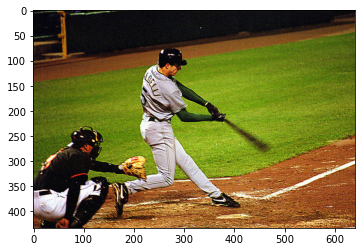

In [14]:
plt.imshow(img)

In [15]:
with open('/home/usman/datasets/coco/raw/person_keypoints_train2017.json', 'r') as file:
    keypoints = json.load(file)

In [16]:
keypoints.keys()

dict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])

# Draw Keypoints

In [17]:
images_df = pd.DataFrame(keypoints['images'])

In [18]:
annotations_df = pd.DataFrame(keypoints['annotations'])

In [19]:
img_id = images_df[images_df['file_name'] == img_name]['id'].values[0]

In [20]:
img_annot = annotations_df[annotations_df['image_id'] == img_id]
img_annot

,segmentation,num_keypoints,area,iscrowd,keypoints,image_id,bbox,category_id,id
128891,"[[161.52, 343.48, 206.28, 335.7, 220.88, 339.5...",15,27886.17465,0,"[292, 116, 2, 0, 0, 0, 287, 110, 2, 0, 0, 0, 2...",323389,"[161.52, 71.03, 251.05, 338.62]",1,487280
252216,"[[3.24, 336.51, 18.65, 308.13, 34.06, 289.48, ...",13,23263.97155,0,"[119, 273, 2, 0, 0, 0, 120, 267, 2, 0, 0, 0, 1...",323389,"[1.62, 230.28, 224.61, 197.04]",1,2157167


In [21]:
img_with_kp = img.copy()
for _kp in img_annot['keypoints'].values:
    img_kp = to_kp_format(flat_arr=_kp)
    img_with_kp = draw_kp_on_image(img_with_kp, img_kp)

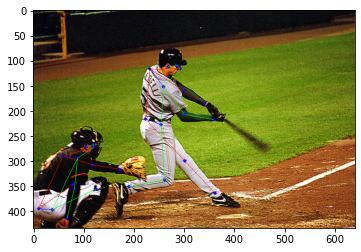

In [22]:
plt.imshow(img_with_kp)